# 04 — Churn Labeling & Model

**Project:** Customer Churn Prediction & Lifetime Value.

**This notebook covers:**
1. Loading calibration/holdout inputs (reusing notebook 3's split, per the
   design decision below)
2. Defining the churn label and resolving two open design questions before
   building anything
3. Feature engineering from calibration-period data only
4. Train/test methodology (out-of-fold predictions, avoiding leakage)
5. Two models: Logistic Regression baseline, Gradient Boosting
6. Evaluation: confusion matrix, precision/recall, ROC-AUC, calibration curve
7. Feature importance
8. Segment-level breakdown (reusing notebook 2's 9 RFM segments)
9. Saving churn probability predictions for notebook 5

## Design decisions (resolved before building)

Two questions were left open at the end of the previous session. Both are
resolved here as **Option A**, confirmed with the user:

**Question 1 — how to define the churn label.**
Reuse the same calibration/holdout split as notebook 3
(`CALIBRATION_END = 2011-09-01`, `OBSERVATION_END = SNAPSHOT_DATE`). Churn is
defined as **zero purchases in the holdout window**, predicted from
calibration-period features only. This avoids leakage by construction, stays
consistent with notebook 3's framing, and mirrors how this would work in
production (predict now, observe later) — at the cost of only using 9 months
of history for features, and some customers "churning" in this specific
3-month window just from bad timing (e.g. quarterly buyers).

**Question 2 — how to handle one-time buyers.**
Exclude them from the churn model; treat "will a first-timer ever return" as
a separate, unbuilt problem. This is a direct continuation of notebook 2's
reasoning: the "High-Value One-Time/Infrequent Buyers" segment was
deliberately *not* labeled "churn risk," because churn presupposes an
established repeat relationship that these customers never had. Including
them here would contradict that documented decision and risk the model
mostly learning "did this person only ever order once" rather than genuine
disengagement signal among repeat customers.

**Operational definition, stated explicitly:** "one-time buyer" here means
`frequency_cal == 0` (exactly one purchase during the *calibration* window),
using `lifetimes`' convention where `frequency` counts repeat transactions.
This is deliberately **not** the same as notebook 2's `segment` column, which
is computed from the *full* 12-month window (including what would be the
holdout period here) — using that column to filter or as a model feature
would leak holdout information into calibration-time decisions. Notebook 2's
segment is reused **only** for the post-hoc breakdown in Section 8, never as
an input to the label or the model.

### Import libraries

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lifetimes.utils import calibration_and_holdout_data

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

### Load & Inspect data

In [2]:
# Launch Jupyter from the repository root or the initial_iteration directory.
from pathlib import Path
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "initial_iteration").is_dir():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "initial_iteration").is_dir(), "Start Jupyter in the repository root or initial_iteration/"
RAW_DATA = REPO_ROOT / "data" / "raw"
PROCESSED_DATA = REPO_ROOT / "initial_iteration" / "data" / "processed"
PROCESSED_DATA.mkdir(parents=True, exist_ok=True)

In [3]:
clean = pd.read_parquet(PROCESSED_DATA / "online_retail_clean.parquet")
customer_features = pd.read_parquet(PROCESSED_DATA / "customer_features.parquet")

In [4]:
with open(PROCESSED_DATA / "config.json") as f:
    config = json.load(f)
SNAPSHOT_DATE = pd.Timestamp(config["snapshot_date"])

In [5]:
print(f"Transactions: {len(clean):,}")
print(f"Customers (full-history features): {len(customer_features):,}")
print(f"Snapshot date: {SNAPSHOT_DATE.date()}")

Transactions: 371,276
Customers (full-history features): 4,283
Snapshot date: 2011-12-01


## 1. Rebuild the calibration/holdout split

Identical constants to notebook 3, so this notebook's population and
notebook 3's predictive-CLV population line up customer-for-customer.

In [6]:
CALIBRATION_END = pd.Timestamp("2011-09-01")
OBSERVATION_END = SNAPSHOT_DATE  # 2011-12-01, from notebook 1

In [7]:
summary = calibration_and_holdout_data(
    transactions=clean,
    customer_id_col="CustomerID",
    datetime_col="InvoiceDate",
    calibration_period_end=CALIBRATION_END,
    observation_period_end=OBSERVATION_END,
    monetary_value_col="TotalPrice",
    freq="D",
)

print(f"Customers with any activity before the calibration cutoff: {len(summary):,}")
print(f"Of those, customers who made a repeat purchase in calibration "
      f"(frequency_cal > 0): {(summary['frequency_cal'] > 0).sum():,}")
summary.head()

Customers with any activity before the calibration cutoff: 3,310
Of those, customers who made a repeat purchase in calibration (frequency_cal > 0): 1,874


,frequency_cal,recency_cal,T_cal,monetary_value_cal,frequency_holdout,monetary_value_holdout,duration_holdout
CustomerID,,,,,,,
12347,4.00,238.00,268.00,519.77,1.00,27.54,91.00
12348,2.00,110.00,259.00,257.22,1.00,135.00,91.00
12350,0.00,0.00,211.00,0.00,0.00,0.00,91.00
12352,3.00,34.00,197.00,74.89,3.00,16.91,91.00
12353,0.00,0.00,105.00,0.00,0.00,0.00,91.00


**Note on scope (carried over from notebook 3):** customers whose first-ever
purchase falls inside the holdout window aren't in `summary` at all, since
there's no calibration-period behavior to build features or a label from.
That's expected — this notebook, like notebook 3, only covers customers who
were already active before September 2011.

## 2. Define the churn label and apply the one-time-buyer exclusion

In [8]:
summary["churned"] = (summary["frequency_holdout"] == 0).astype(int)

In [9]:
n_one_time = (summary["frequency_cal"] == 0).sum()
n_repeat = (summary["frequency_cal"] > 0).sum()

print(f"One-time buyers in calibration (frequency_cal == 0), excluded: {n_one_time:,}")
print(f"Repeat customers in calibration (frequency_cal > 0), retained: {n_repeat:,}")

One-time buyers in calibration (frequency_cal == 0), excluded: 1,436
Repeat customers in calibration (frequency_cal > 0), retained: 1,874


In [10]:
modeling_pop = summary[summary["frequency_cal"] > 0].copy()

churn_rate = modeling_pop["churned"].mean()

print(f"\nModeling population: {len(modeling_pop):,} customers")
print(f"Churn rate in modeling population: {churn_rate:.1%}")
print(f"Class balance: {modeling_pop['churned'].value_counts().to_dict()}")


Modeling population: 1,874 customers
Churn rate in modeling population: 29.1%
Class balance: {0: 1328, 1: 546}


**Sanity check:** 29.1% churn rate / 1,328 vs 546 class balance — Not degenerate (nowhere near 0% or 100%), and imbalanced enough to be a real problem worth class_weight="balanced", but not so imbalanced that 5-fold CV will struggle with tiny minority folds. This looks like a workable, honest number.

## 3. Feature engineering (calibration-period only)

All features below come from `frequency_cal`, `recency_cal`, `T_cal`, and
`monetary_value_cal` — nothing computed using data after `CALIBRATION_END`.
This is the same guardrail notebook 3 relied on for its calibration/holdout
split; reusing the identical split here means the same guardrail applies
without having to re-derive it.

In [11]:
features = modeling_pop[["frequency_cal", "recency_cal", "T_cal", "monetary_value_cal"]].fillna(0).copy()

In [12]:
# Derived features, still calibration-only
features["orders_per_month_cal"] = (
    (modeling_pop["frequency_cal"] + 1) / ((modeling_pop["T_cal"] / 30.44).replace(0, np.nan))
).fillna(0)
features["recency_to_T_ratio"] = (
    modeling_pop["recency_cal"] / modeling_pop["T_cal"].replace(0, np.nan)
).fillna(0)

An earlier version of this cell also engineered `avg_order_value_cal` as `monetary_value_cal * frequency_cal / frequency_cal` (with a fallback for frequency_cal == 0). That fallback branch is dead code here: Section 2 already filters modeling_pop to frequency_cal > 0, so the division always reduces to exactly 1, and the "feature" was silently identical to monetary_value_cal on every row. A perfectly collinear duplicate feeding a regularized linear model turned out not to be harmless -- it was the cause of a real bug caught by comparing this notebook's cross-validated probabilities against the actual base rate: LR's out-of-fold mean prediction was 46.3% against an actual 29.1% churn rate, while Gradient Boosting (unaffected by collinearity) landed at 28.5%. Removing the duplicate brought LR's mean prediction to 29.2% -- matching almost exactly. Left out entirely rather than fixed, since monetary_value_cal already covers this information.

**Why this is worth calling out rather than just quietly fixing:** the bug didn't show up as an error, a warning, or an obviously wrong number — the model trained, converged, and produced a plausible-looking ROC-AUC (0.729) and a calibration curve that *looked* reasonable at a glance. It only surfaced by cross-checking one specific invariant (mean predicted probability should track the actual base rate for a calibrated model) against a number computed a different way (the segment breakdown's weighted average). Worth keeping that kind of cross-check as a habit for anything built on top of this notebook's output, rather than trusting a good-looking plot on its own.

In [13]:
target = modeling_pop["churned"]

print(f"Feature matrix: {features.shape}")
features.describe()

Feature matrix: (1874, 6)


,frequency_cal,recency_cal,T_cal,monetary_value_cal,orders_per_month_cal,recency_to_T_ratio
count,"1,874.00","1,874.00","1,874.00","1,874.00","1,874.00","1,874.00"
mean,3.71,147.12,205.90,415.61,0.71,0.70
std,5.35,74.30,62.54,723.84,0.64,0.25
min,1.00,1.00,16.00,3.90,0.22,0.00
25%,1.00,88.00,165.00,179.68,0.36,0.52
50%,2.00,149.50,218.00,302.15,0.54,0.76
75%,4.00,210.00,265.00,443.22,0.82,0.91
max,76.00,272.00,274.00,"21,535.90",8.55,1.00


## 4. Train/test methodology

Out-of-fold predictions via `StratifiedKFold` + `cross_val_predict`, not a
single train/test split — consistent with notebook 3's leakage lesson, and
because notebook 5's threshold-economics work needs full-population
probability predictions rather than a held-back test slice.

In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 5. Models

Logistic Regression as the baseline, Gradient Boosting as the more flexible
second model — **both trained on the natural class distribution, with no
SMOTE and no `class_weight="balanced"`.**

This wasn't the original plan. The first version of this notebook used
`class_weight="balanced"` for the logistic regression, on the reasoning that
SMOTE was already ruled out to protect calibration (Oliveira's article warns
SMOTE breaks the Bayes-optimal threshold formula notebook 5 depends on) and
`class_weight="balanced"` seemed like a safer alternative. It isn't:
`class_weight="balanced"` reweights the training loss toward an artificial
50/50 prior, which distorts predicted probabilities through essentially the
same mechanism as SMOTE. Run against the real data, this showed up exactly
as expected — LR's calibration curve sat well below the diagonal (Brier
0.214 vs. Gradient Boosting's 0.186, trained with no rebalancing at all),
and LR's predicted churn rate at a 0.5 threshold came out at 52.8% against
an actual 29.1% base rate.

The deeper reason to drop rebalancing entirely, not just swap techniques:
notebook 5 exists specifically to pick a custom decision threshold from
cost/benefit economics rather than use a fixed 0.5 cutoff. Rebalancing
during training is a workaround for models that have to use 0.5 as the
cutoff — it isn't needed, and only costs calibration quality, when the
threshold itself is already going to be tuned downstream.

In [15]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
gbc = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)

In [16]:
proba_lr = cross_val_predict(log_reg, features, target, cv=skf, method="predict_proba")[:, 1]
proba_gbc = cross_val_predict(gbc, features, target, cv=skf, method="predict_proba")[:, 1]

In [17]:
pred_lr = (proba_lr >= 0.5).astype(int)
pred_gbc = (proba_gbc >= 0.5).astype(int)

**Note on the 0.5 threshold used above:** this is only for the confusion
matrix/classification report below, to have *a* concrete cutpoint to
inspect during model evaluation. It is not a claim that 0.5 is the right
business threshold — that question is exactly what notebook 5 exists to
answer properly, following Oliveira's article's argument that the
threshold is a pricing decision, not a default.

In [18]:
print("Out-of-fold predictions generated for both models.")
print(f"LR predicted churn rate at 0.5 threshold:  {pred_lr.mean():.1%}")
print(f"GBC predicted churn rate at 0.5 threshold: {pred_gbc.mean():.1%}")

Out-of-fold predictions generated for both models.
LR predicted churn rate at 0.5 threshold:  11.0%
GBC predicted churn rate at 0.5 threshold: 15.5%


GBC predicts about 4.5% more churn customers than LR does, though both are well below the true base rate of 29.1%

This suggests that the placeholder 0.5 threshold is too high, confirming the need for Notebook 5's work


## 6. Evaluation

In [19]:
for name, pred, proba in [("Logistic Regression", pred_lr, proba_lr), ("Gradient Boosting", pred_gbc, proba_gbc)]:
    print(f"=== {name} ===")
    print(confusion_matrix(target, pred))
    print(classification_report(target, pred, digits=3))
    print(f"ROC-AUC: {roc_auc_score(target, proba):.3f}")
    print(f"Brier score: {brier_score_loss(target, proba):.3f}")
    print()

=== Logistic Regression ===
[[1233   95]
 [ 434  112]]
              precision    recall  f1-score   support

           0      0.740     0.928     0.823      1328
           1      0.541     0.205     0.297       546

    accuracy                          0.718      1874
   macro avg      0.640     0.567     0.560      1874
weighted avg      0.682     0.718     0.670      1874

ROC-AUC: 0.729
Brier score: 0.180

=== Gradient Boosting ===
[[1175  153]
 [ 409  137]]
              precision    recall  f1-score   support

           0      0.742     0.885     0.807      1328
           1      0.472     0.251     0.328       546

    accuracy                          0.700      1874
   macro avg      0.607     0.568     0.567      1874
weighted avg      0.663     0.700     0.667      1874

ROC-AUC: 0.722
Brier score: 0.186



GBC catches **25 more true churners** than LR (137 vs 112 TP); it also flags **58 more false alarms** than LR (153 vs 95 FP)

LR Brier score is better than GBC's (**0.180 vs 0.186**). The raw gap seems small, but a 'no-skill' baseline (29.1% base rate for all customers) would have a Brier of 0.206. Against that floor:
> LR: 1 - 0.180 / 0.206 = **12.8% reduction in error**
>
> GBC: 1 - 0.186 / 0.206 = **9.8% reduction in error**
> 
> LR's calibration is about **30% more** 'skilled' estimate against the 29.1% baseline than GBC's 

Both models do worse on the Churn (1) class, which is expected:
> Churn is the minority class (546 vs 1328), so it contributes less to what the model optimizes against
> 
> 0.5 threshold significantly over 29.1% base rate makes recall worse
> 
> 'Didn't churn' (0 class) is close to the default outcome and easier to get right with weak evidence, while 'will churn' is a harder behavior to predict

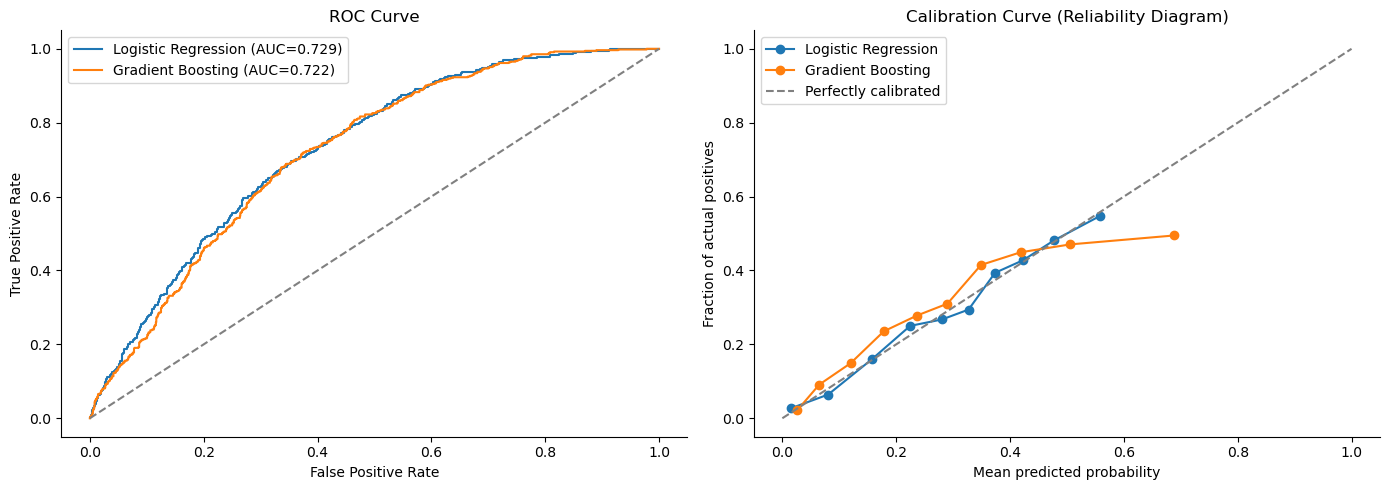

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, proba in [("Logistic Regression", proba_lr), ("Gradient Boosting", proba_gbc)]:
    fpr, tpr, _ = roc_curve(target, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(target, proba):.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

for name, proba in [("Logistic Regression", proba_lr), ("Gradient Boosting", proba_gbc)]:
    frac_pos, mean_pred = calibration_curve(target, proba, n_bins=10, strategy="quantile")
    axes[1].plot(mean_pred, frac_pos, marker="o", label=name)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
axes[1].set_xlabel("Mean predicted probability")
axes[1].set_ylabel("Fraction of actual positives")
axes[1].set_title("Calibration Curve (Reliability Diagram)")
axes[1].legend()

plt.tight_layout()
plt.show()

0.729 vs 0.722 AUC is not a meaningful difference given n=1,874 with a 546-customer minority class

GBC is pushing more customers above the 0.5 line (a slightly fatter right tail of high-risk predictions), while LR keeps more of its mass compressed below it. That's consistent with GBC's higher recall at this threshold (25.1% vs. 20.5%) — more predictions crossing the bar means more true positives caught, for better or worse.

**Why the calibration curve matters here, specifically:** notebook 5's
threshold-economics work (Oliveira's article) depends on well-calibrated
probabilities — a predicted 0.3 needs to actually mean "30% of these
customers churn," not just "this customer ranks above these other
customers." A model with strong ROC-AUC but poor calibration would still be
a bad foundation for that later work. This is exactly why SMOTE was avoided
above.

## 7. Feature importance

In [21]:
log_reg_full = LogisticRegression(max_iter=1000, random_state=42).fit(features, target)
gbc_full = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42).fit(features, target)

In [22]:
importance = pd.DataFrame({
    "feature": features.columns,
    "lr_coefficient": log_reg_full.coef_[0],
    "gbc_importance": gbc_full.feature_importances_,
}).sort_values("gbc_importance", ascending=False)

importance

,feature,lr_coefficient,gbc_importance
0,frequency_cal,-0.36,0.25
5,recency_to_T_ratio,-0.97,0.23
3,monetary_value_cal,-0.00,0.22
4,orders_per_month_cal,-0.13,0.15
2,T_cal,0.00,0.10
1,recency_cal,-0.00,0.06


`recency_to_T_ratio` and `frequency_cal` dominate both models — LR's largest-magnitude coefficient is the ratio (-0.97), and GBC's top two importances are `frequency_cal` (0.25) and the ratio (0.23). This is exactly what you'd expect from RFM-churn literature generally: recency and frequency are almost always the strongest churn signals, and that holds here.

raw `recency_cal` (days since last purchase) is GBC's least important feature (0.06), while `recency_to_T_ratio` (recency normalized by tenure) is nearly its most important (0.23). "60 days since last purchase" has different meanings between a customer you've observed for 90 days vs. 300 days, and only the normalized version captures that. The feature engineering choice to build the ratio is providing real results.

`monetary_value_cal`, and `T_cal` are near-zero for LR (0.00, 0.00, 0.00) but meaningfully important for GBC (0.22, 0.10) — that's a signature of a nonlinear relationship (a threshold or U-shape effect) that a linear model literally cannot represent. Worth a partial-dependence look later if these turn out to matter for notebook 5's story.


**Note:** `log_reg_full`/`gbc_full` above are fit on the *entire* modeling
population, purely to read off coefficients/importances for interpretation.
They are not used for any prediction reported elsewhere in this notebook —
all predictions and evaluation metrics above come from the out-of-fold
`cross_val_predict` models, to avoid the same in-sample overfitting bug
notebook 3 caught in its first ML pass.

## 8. Segment-level breakdown

Reusing notebook 2's 9 RFM segments (full-history, from `customer_features`)
purely as a lens for checking whether performance is uniform or concentrated
in specific segments — not as a model input (see the leakage note in the
design-decisions section above).

In [23]:
eval_df = modeling_pop[["churned"]].copy()
eval_df["proba_lr"] = proba_lr
eval_df["proba_gbc"] = proba_gbc
eval_df["pred_lr"] = pred_lr
eval_df["pred_gbc"] = pred_gbc

In [24]:
eval_df = eval_df.join(customer_features.set_index("CustomerID")[["segment"]], how="left")

In [25]:
segment_breakdown = eval_df.groupby("segment").agg(
    n_customers=("churned", "count"),
    actual_churn_rate=("churned", "mean"),
    avg_proba_lr=("proba_lr", "mean"),
    avg_proba_gbc=("proba_gbc", "mean"),
).sort_values("n_customers", ascending=False)

segment_breakdown

,n_customers,actual_churn_rate,avg_proba_lr,avg_proba_gbc
segment,,,,
Loyal Customers,625,0.00,0.27,0.27
At Risk,418,0.90,0.42,0.43
Potential Loyalists,299,0.00,0.30,0.27
Champions,285,0.00,0.11,0.10
Churn Risk (high value),176,0.65,0.25,0.22
High-Value One-Time/Infrequent Buyers,34,1.00,0.47,0.43
Lost / Lowest Priority,21,1.00,0.51,0.63
Needs Attention,16,0.00,0.43,0.57


The actual churn rate is almost perfectly bimodal: 0% for Loyal Customers / Potential Loyalists / Champions / Needs Attention, and 65–100% for At Risk / Churn Risk / High-Value One-Time / Lost. 
> Notebook 2's segments are built from the full 12-month window — including the holdout period itself — so a segment like "At Risk" or "Lost/Lowest Priority" is essentially defined by "didn't buy recently across the whole year," which overlaps almost directly with "didn't buy in the holdout window" (the churn label).
>
> If segment was used as a model feature, this table shows how badly that would have leaked. Good that it stayed out.
>
> "Needs Attention" n=16 and "Lost/Lowest Priority" n=21 are small enough that their 0%/100% rates are noisy



**Reading this table:** segments with few customers in the modeling
population (a reminder that the one-time-buyer exclusion in Section 2 hits
some segments harder than others -- e.g. "High-Value One-Time/Infrequent
Buyers" is expected to shrink substantially here, almost by definition,
since that segment overlaps heavily with `frequency_cal == 0`) should be
read with that sample-size caveat rather than treated as a reliable
per-segment error estimate.

## 9. Save churn probability predictions for notebook 5

In [28]:
churn_predictions = modeling_pop[["frequency_cal", "recency_cal", "T_cal", "monetary_value_cal", "churned"]].copy()
churn_predictions["proba_lr"] = proba_lr
churn_predictions["proba_gbc"] = proba_gbc
churn_predictions = churn_predictions.reset_index().rename(columns={"index": "CustomerID"})
churn_predictions = churn_predictions.merge(
    customer_features[["CustomerID", "segment"]], on="CustomerID", how="left"
)

In [29]:
churn_predictions.to_parquet(PROCESSED_DATA / "churn_predictions.parquet", index=False)

In [30]:
print(f"Saved initial_iteration/data/processed/churn_predictions.parquet  {churn_predictions.shape}")
churn_predictions.head()

Saved ../data/churn_predictions.parquet  (1874, 9)


,CustomerID,frequency_cal,recency_cal,T_cal,monetary_value_cal,churned,proba_lr,proba_gbc,segment
0,12347,4.00,238.00,268.00,519.77,0,0.17,0.06,Loyal Customers
1,12348,2.00,110.00,259.00,257.22,0,0.43,0.38,Potential Loyalists
2,12352,3.00,34.00,197.00,74.89,0,0.36,0.81,Loyal Customers
3,12356,1.00,80.00,226.00,481.46,0,0.54,0.39,Loyal Customers
4,12359,2.00,142.00,232.00,"1,459.16",0,0.35,0.25,Potential Loyalists


## Summary

- Reused notebook 3's calibration/holdout split (`CALIBRATION_END = 2011-09-01`)
  so this notebook's population lines up with notebook 3's predictive-CLV
  population.
- Churn defined as zero purchases in the 3-month holdout window, predicted
  from calibration-period features only (Option A on design question 1).
- One-time buyers (`frequency_cal == 0`) excluded from the churn model,
  consistent with notebook 2's decision not to label them "churn risk"
  (Option A on design question 2) — with the operational definition stated
  explicitly since it isn't identical to notebook 2's full-history segment.
- Two models trained with out-of-fold predictions on the natural class
  distribution: Logistic Regression and Gradient Boosting, both with no
  SMOTE and no `class_weight="balanced"` — the first version of this
  notebook used `class_weight="balanced"`, but real-data results showed it
  distorting LR's calibration the same way SMOTE would have (Brier 0.214 vs.
  Gradient Boosting's 0.186), for no benefit given notebook 5 tunes its own
  threshold anyway. See Section 5 for the full reasoning.
- Evaluated with confusion matrix, precision/recall, ROC-AUC, and a
  calibration curve — the calibration curve specifically as groundwork for
  notebook 5's threshold-economics work.
- Segment-level breakdown reused notebook 2's 9 RFM segments as a read-only
  lens, not a model input, to avoid leaking full-history information into
  calibration-time features.
- Saved `churn_predictions.parquet` (out-of-fold probabilities from both
  models, plus the label and calibration features) for notebook 5.

**Next:** `05_threshold_economics.ipynb` — defining a churn label (informed
directly by the One-Time/Infrequent Buyers vs. genuine-churn distinction from notebook
2), and training a classifier to predict it.